# Importing all the necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import joblib 
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
    PassiveAggressiveClassifier
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import cross_val_score


# Reading CSV file

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


# Trying to visualise the data using Plotting and analysing value

In [4]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
df.info()   #Output of this is cleary showing that there is no missing value. 
            #This is a very useful information.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
set(df['smoking_history'])

{'No Info', 'current', 'ever', 'former', 'never', 'not current'}

In [7]:
set(df['gender'])

{'Female', 'Male', 'Other'}

# Visualising the number of people having diabetes and people not having diabetes

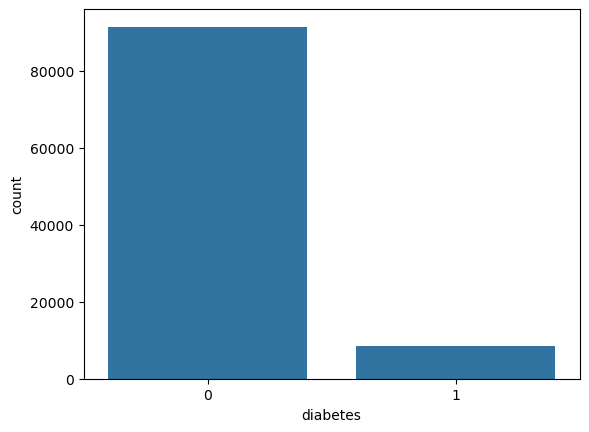

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="diabetes",data=df)

plt.show()

In [9]:
yes_diabetes = (df['diabetes'] == 1).sum()
no_diabetes = (df['diabetes'] == 0).sum()

In [10]:
yes_diabetes

np.int64(8500)

In [11]:
no_diabetes

np.int64(91500)

In [12]:
yes_diabetes_male = ((df['diabetes'] == 1) & (df['gender'] == 'Male')).sum()
no_diabetes_male = ((df['diabetes'] == 0) & (df['gender'] == 'Male')).sum()

In [13]:
yes_diabetes_male

np.int64(4039)

In [14]:
no_diabetes_male

np.int64(37391)

In [15]:
yes_diabetes_female = ((df['diabetes'] == 1) & (df['gender'] == 'Female')).sum()
no_diabetes_female = ((df['diabetes'] == 0) & (df['gender'] == 'Female')).sum()

In [16]:
yes_diabetes_female

np.int64(4461)

In [17]:
no_diabetes_female

np.int64(54091)

# Trying to compare the diabetic and non-diabetic person belonging to which Gender

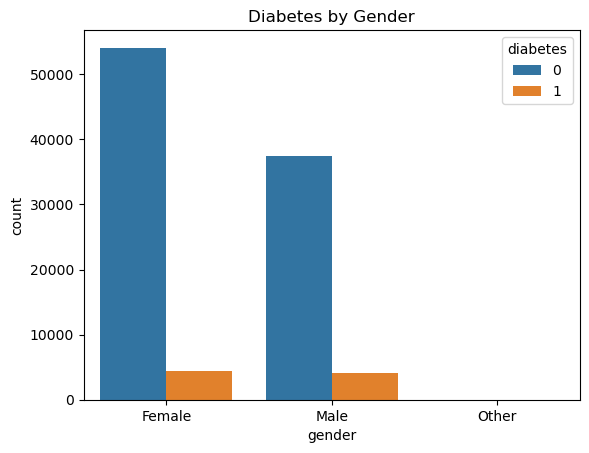

In [18]:
sns.countplot(x="gender", hue="diabetes", data=df)
plt.title("Diabetes by Gender")
plt.show()

# Plotting Heatmap to see the correlation between variables

<Axes: >

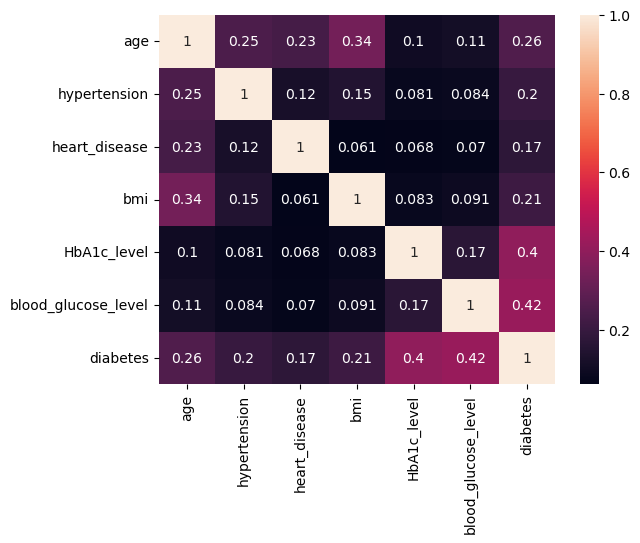

In [19]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Boxplot is for visualising which age-group is affected more with diabetes. It help us to know about the outliers

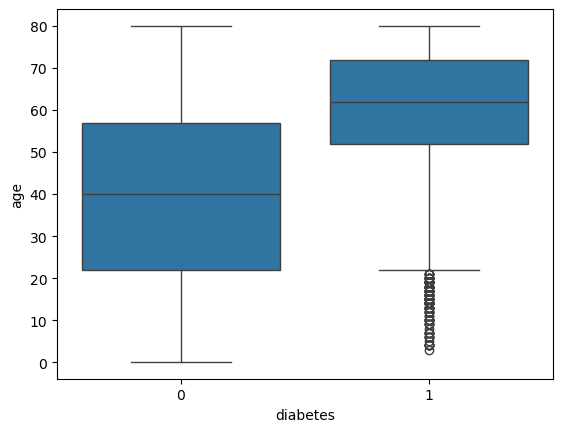

In [20]:
sns.boxplot(x="diabetes", y="age", data=df)
plt.show()

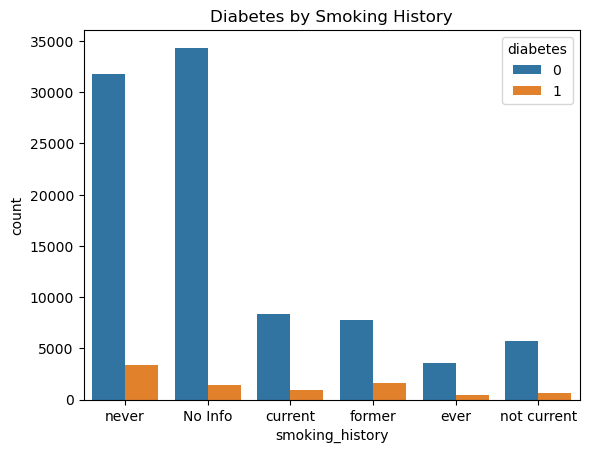

In [21]:
sns.countplot(x="smoking_history", hue="diabetes", data=df)
plt.title("Diabetes by Smoking History")
plt.show()

In [22]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [23]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


# Stratified shuffling for spliting train and test set

In [24]:
split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, test_idx in split.split(df, df["diabetes"]):
    train_set = df.iloc[train_idx]
    test_set = df.iloc[test_idx]


# In train set, separating out label column and feature columns

In [25]:
df_features = train_set.drop("diabetes",axis =1)
df_labels = train_set['diabetes']

In [26]:
# Now feature and label column are separated, so now in feature column, keeping column belonging to numerical value in 
# a separate series(num_cols) and similiarly categorical column in another series(cat_cols)

num_cols = df_features.select_dtypes(include=["int64", "float64"]).columns

cat_cols = df_features.select_dtypes(include=["object", "category"]).columns

# Creating Pipeline to fit different Procedure such as Imputers, scaling for feature scaling and models for prediction

In [27]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

from sklearn.preprocessing import OneHotEncoder
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

fin_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Creating List of models and iterating over each models with cross validation check to check the accuracy of each model

In [28]:
results = []
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    #"Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "SGD Classifier": SGDClassifier(random_state=42)
}
for name, model in models.items():

    pipeline = Pipeline([
        ("finalPipeline", fin_pipeline),
        ("classifier", model)
    ])

    scores = cross_val_score(
        pipeline,
        df_features,
        df_labels,
        cv=10,
        scoring="accuracy"
    )

    results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("Mean Accuracy", ascending=False))

                 Model  Mean Accuracy       Std
1        Random Forest       0.969487  0.001365
3                  SVM       0.963900  0.002008
4                  KNN       0.960487  0.001774
0  Logistic Regression       0.960200  0.001499
5       SGD Classifier       0.959725  0.001854
2        Decision Tree       0.951288  0.002484


# After checking the Accuracy of each model, passing the most accurate model in Pipeline and predicting the output

In [29]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

from sklearn.preprocessing import OneHotEncoder
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

fin_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])
pipeline = Pipeline([
        ("finalPipeline", fin_pipeline),
        ("classifier", RandomForestClassifier(random_state=42))
    ])
pipeline.fit(df_features, df_labels)

,steps,"[('finalPipeline', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
test_features = test_set.drop('diabetes',axis=1) 
test_features

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
69456,Female,36.0,0,0,former,22.64,6.0,160
86614,Female,31.0,0,0,never,27.32,5.8,126
61660,Male,52.0,0,0,not current,23.20,4.0,100
8558,Female,29.0,0,0,never,30.57,5.0,160
4619,Male,61.0,0,0,never,26.88,5.8,90
...,...,...,...,...,...,...,...,...
4738,Female,22.0,0,0,No Info,20.30,4.0,80
89031,Female,38.0,0,0,never,23.60,3.5,130
59812,Female,38.0,0,0,never,26.57,6.2,159
17244,Female,78.0,0,0,No Info,27.32,5.8,85


In [31]:
predictions = pipeline.predict(test_features)
print(len(predictions))

20000


In [32]:
(test_set['diabetes'] == 1).sum()

np.int64(1700)

In [33]:
i = 0
cnt = 0
for predict in predictions:
    if(predict == test_set['diabetes'].iloc[i]):
        cnt+=1
        
    i+=1
print(cnt)

19395


In [34]:
def cal_percentage(total_count,accurate_count):
    return ((accurate_count)/total_count)*100
total_count = len(predictions)
accurate_count = cnt
corr_percentage = cal_percentage(total_count,accurate_count)
print(f"Accuracy Rate is {corr_percentage}%")



Accuracy Rate is 96.975%
